In [ ]:
import sys
sys.path.insert(0, '..')
import kagglehub
import pandas as pd
import numpy as np
from data.dataset import load_raw_data

df = load_raw_data()


print("\n--- Raw Data Info ---")
df.info()

print("\n--- Head of Data ---")
display(df.head())

Path to dataset files: /Users/fe-edward/.cache/kagglehub/datasets/qingyi/wm811k-wafer-map/versions/1
Loading data... (Please wait)

--- Raw Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   waferMap        811457 non-null  object 
 1   dieSize         811457 non-null  float64
 2   lotName         811457 non-null  object 
 3   waferIndex      811457 non-null  float64
 4   trianTestLabel  811457 non-null  object 
 5   failureType     811457 non-null  object 
dtypes: float64(2), object(4)
memory usage: 37.1+ MB

--- Head of Data ---


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],none
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],none
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],none
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],none
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],none


## 整理資料與 EDA

為原始資料增加欄位，以方便訓練模型與分析資料。
  - failureType ndArray → 字串(待確認)

無標記資料數： 638507
已標注資料數量： 172950
其中有缺陷模式和無缺陷模式的數量：
/ 無缺陷模式數量： 147431
/ 缺陷模式數量： 25519


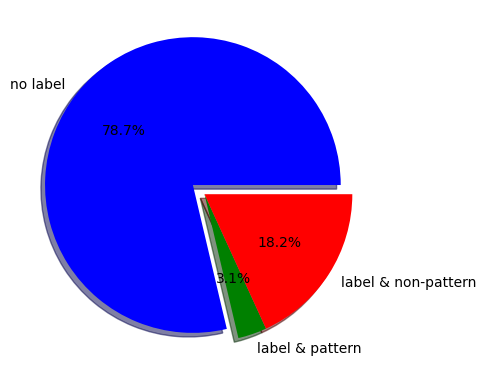

In [5]:
import matplotlib.pyplot as plt
from data.dataset import extract_labeled_patterned_data

# 標記資料分布

df_with_label, df_with_pattern, df_without_pattern = extract_labeled_patterned_data(df)

def calc_labeled_pattern_num(df_with_label, df_with_pattern, df_without_pattern):
  num_labeled = df_with_label.shape[0]
  num_none_labeled = len(df['waferMap']) - num_labeled
  num_labeled_pattern = df_with_pattern.shape[0]
  num_labeled_nonpattern = df_without_pattern.shape[0]

  return num_labeled, num_none_labeled, num_labeled_pattern, num_labeled_nonpattern

num_labeled, num_none_labeled, num_labeled_pattern, num_labeled_nonpattern = calc_labeled_pattern_num(df_with_label, df_with_pattern, df_without_pattern)


print(f"無標記資料數： {num_none_labeled}")
print(f"已標注資料數量： {num_labeled}")
print("其中有缺陷模式和無缺陷模式的數量：")
print(f"/ 無缺陷模式數量： {num_labeled_nonpattern}")
print(f"/ 缺陷模式數量： {num_labeled_pattern}")


colors = ['blue', 'green', 'red']
num_wafers=[num_none_labeled, num_labeled_pattern, num_labeled_nonpattern]
labels = ['no label', 'label & pattern', 'label & non-pattern']
plt.pie(num_wafers, explode=(0.1,0,0), labels = labels, colors = colors, autopct = '%1.1f%%', shadow=True)

plt.show()

In [ ]:
failure_types = df_with_pattern['failureType'].value_counts().index

for i, failure_name in enumerate(failure_types):
  print(failure_name)

print(df_with_pattern['failureType'] == 'Loc')

Edge-Ring
Edge-Loc
Center
Loc
Scratch
Random
Donut
Near-full
0         True
1        False
2        False
3        False
4        False
         ...  
25514    False
25515    False
25516    False
25517    False
25518    False
Name: failureType, Length: 25519, dtype: bool


failureType
Edge-Ring    9680
Edge-Loc     5189
Center       4294
Loc          3593
Scratch      1193
Random        866
Donut         555
Near-full     149
Name: count, dtype: int64


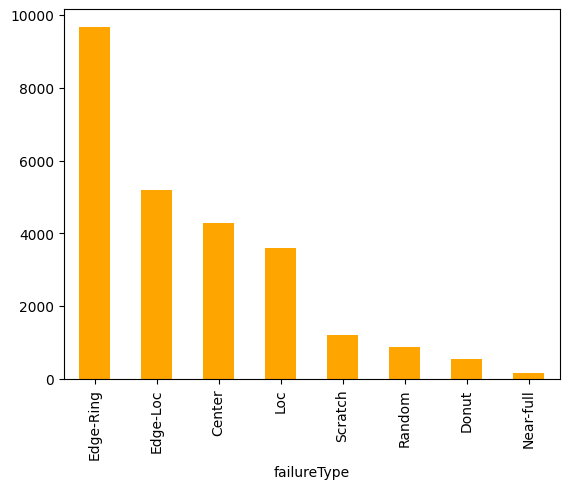

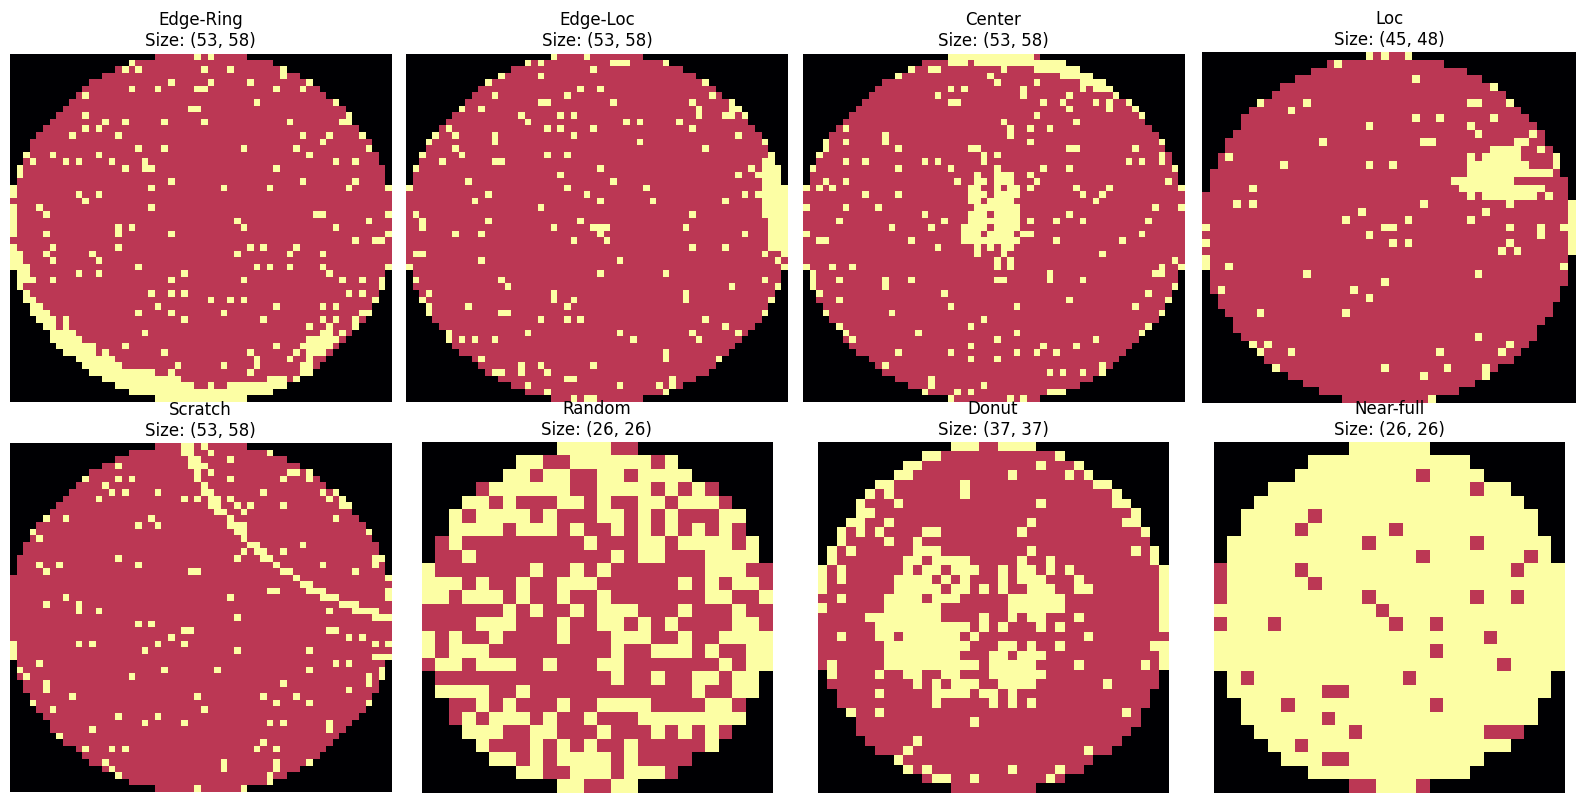

In [6]:

# 缺陷模式種類分布
df_with_pattern['failureType'].value_counts().plot(kind='bar', color='orange')
print(df_with_pattern['failureType'].value_counts())

failure_types = df_with_pattern['failureType'].value_counts().index

fig, ax = plt.subplots(2, 4, figsize=(16, 8))
ax = ax.ravel()

for i, failure_name in enumerate(failure_types):
    if failure_name == 'none':
        continue

    wafer = df_with_pattern[df_with_pattern['failureType'] == failure_name].iloc[0]
    wafer_map = wafer['waferMap']

    ax[i].imshow(wafer_map, cmap='inferno')

    ax[i].set_title(f"{failure_name}\nSize: {wafer_map.shape}")
    ax[i].axis('off')

plt.tight_layout()
plt.show()

In [7]:
# 計算圖像的維度
def find_dim(x):
    dim0 = np.size(x, axis=0)
    dim1 = np.size(x, axis=1)
    return dim0, dim1
df_with_label['waferMapDim']= df['waferMap'].apply(lambda x: find_dim(x))
df_with_label[['waferMap', 'lotName', 'waferIndex', 'waferMapDim']].head(5)

,waferMap,lotName,waferIndex,waferMapDim
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",lot1,1.0,"(45, 48)"
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",lot1,2.0,"(45, 48)"
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",lot1,3.0,"(45, 48)"
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",lot1,4.0,"(45, 48)"
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",lot1,5.0,"(45, 48)"


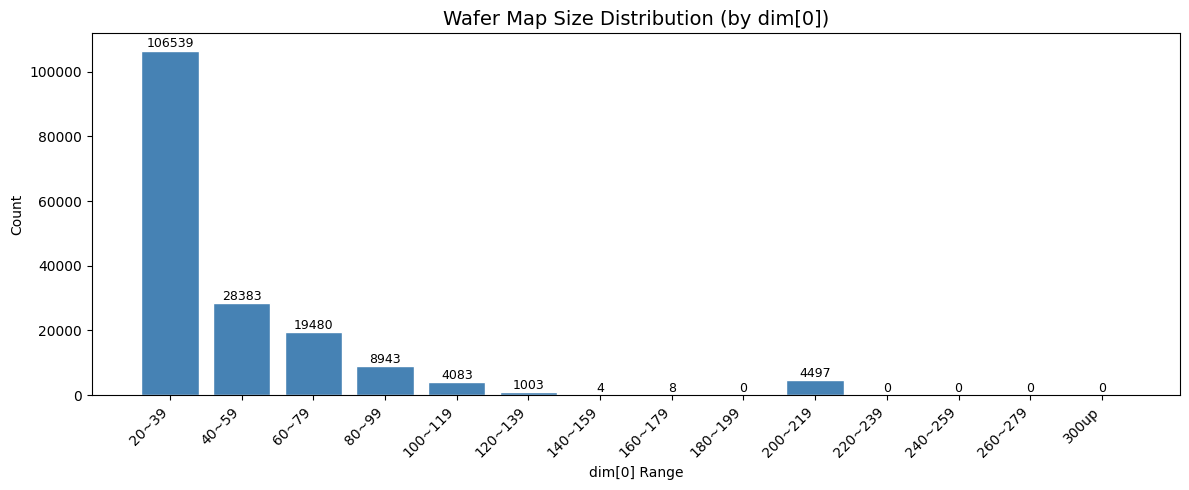

waferMapDim
20~39      106539
40~59       28383
60~79       19480
80~99        8943
100~119      4083
120~139      1003
140~159         4
160~179         8
180~199         0
200~219      4497
220~239         0
240~259         0
260~279         0
300up           0
Name: count, dtype: int64


In [8]:
# 統計資料尺寸（以 dim[0] 分級距）
dim0_series = df_with_label['waferMapDim'].apply(lambda x: x[0])

bins = list(range(20, 300, 20)) + [float('inf')]
labels = [f'{bins[i]}~{bins[i+1]-1}' for i in range(len(bins)-2)] + ['300up']

dim0_binned = pd.cut(dim0_series, bins=bins, labels=labels, right=False)
bin_counts = dim0_binned.value_counts().sort_index()

plt.figure(figsize=(12, 5))
bars = plt.bar(bin_counts.index, bin_counts.values, color='steelblue', edgecolor='white')
for bar, val in zip(bars, bin_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
             str(val), ha='center', va='bottom', fontsize=9)
plt.title('Wafer Map Size Distribution (by dim[0])', fontsize=14)
plt.xlabel('dim[0] Range')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(bin_counts)

經過統計，前 10 多的尺寸介於 25~44 之間，取中間最常見的 32*32 作為 Resize 目標尺寸。